In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Load and filter data
df = pd.read_csv('house_prices.csv')
df.fillna({'price': 0, 'bedrooms': 0, 'sqft_living': 0, 'sqft_lot': 0, 'sqft_above': 0, 'bathrooms': 0}, inplace=True)
mask = df['bedrooms'].isin([3, 4, 5])
filtered_df = df[mask]


In [46]:
# Features and target
X = filtered_df[['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']] #Features
y = filtered_df['price'] #target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_test


364     522500.0
3992    148612.5
3734    409124.0
880     800000.0
334     275000.0
          ...   
2215    440000.0
3536    295000.0
3033    220000.0
220     340000.0
619     330000.0
Name: price, Length: 707, dtype: float64

In [40]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Model R² Score: {model.score(X_test, y_test):.2f}")

Model R² Score: 0.24


In [41]:
# Predict and evaluate
y_pred = model.predict(X_test)
print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")


First 5 predictions: [635030.92273903 261967.643622   793917.48659734 688975.31150258
 405084.16518146]
First 5 actual prices: [522500.  148612.5 409124.  800000.  275000. ]


In [42]:
# Calculate prediction errors
import numpy as np
errors = y_test.values - y_pred
print(f"First 5 prediction errors: {errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.1f}")

First 5 prediction errors: [-112530.92273903 -113355.143622   -384793.48659734  111024.68849742
 -130084.16518146]
Mean Absolute Error: 207827.2


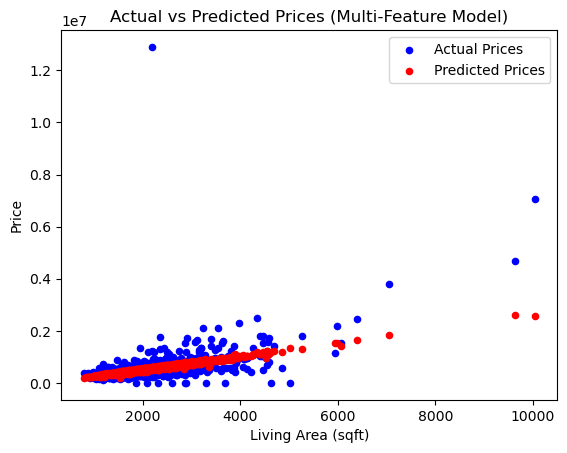

In [48]:
import matplotlib.pyplot as plt

# Visualize predictions (using sqft_living for x-axis)
plot_df = pd.DataFrame({
    'sqft_living': X_test['sqft_living'],
    'actual_price': y_test,
    'predicted_price': y_pred
})
ax = plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='red', label='Predicted Prices', ax=ax)
ax.set_xlabel('Living Area (sqft)')
ax.set_ylabel('Price')
ax.set_title('Actual vs Predicted Prices (Multi-Feature Model)')
plt.savefig('multi_feature_predictions.png')
plt.show()